In [1]:
# To run only once or else restart the kernel
# or change manually the current directory so that it is Networks_project/
import os
os.chdir("../")

In [2]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats
import itertools
import random 

from src.network_utils import constitution_df, construction_reseau, degree_distribution, afficher_infos_reseau, logBinning, degree_distribution, plot_stacked_degree_categories, build_location_users, add_location_popularity, popularity_club_coefficient

# 1.Téléchargement des données et constitution des dataframes

In [3]:
path_data_check_in='data/dataset_TSMC2014_TKY.txt'
path_data_users='data/dataset_UbiComp2016_UserProfile_TKY.txt'

df_check_in = pd.read_csv(
        path_data_check_in,
        sep='\t',
        encoding='latin-1',
        header=None,
        names=[
            'user_id','location_id','location_type_ID',
            'location_type_name','latitude','longitude',
            'timezone','timestamp', 'Venue_Category_Name'
        ]
    )

df_users = pd.read_csv(
        path_data_users,
        sep='\t',
        encoding='latin-1',
        header=None,
        names=[
            'user_id','gender','nb_twitter_friends',
            'nb_twitter_followers'
        ]
    )

dfjoint_complet, dfjoint_micro, dfjoint_macro=constitution_df(path_data_check_in,path_data_users )


In [4]:
# Distribution du nombre de followers parmi les users

dfjoint_complet['nb_twitter_followers'].quantile(
    [i/10 for i in range(1, 10)]
)

0.1     120.5
0.2     217.0
0.3     326.0
0.4     473.0
0.5     661.5
0.6     873.0
0.7    1084.0
0.8    1427.0
0.9    2360.0
Name: nb_twitter_followers, dtype: float64

Nous ne pouvons malheureusement connaître le nombre de followers que pour une minorité des utilisateurs. Nos résultats devront donc être interprétés avec prudence.

In [5]:
set_a = set(df_check_in['user_id'].astype(str))
set_b = set(df_users['user_id'].astype(str))

intersection = set_a.intersection(set_b)
uniquement_checkins = set_a - set_b
uniquement_users = set_b - set_a

print(f"\n--- Analyse des Ensembles ---")
print(f"IDs uniquement dans Check-ins : {len(uniquement_checkins)}")
print(f"IDs uniquement dans Users     : {len(uniquement_users)}")
print(f"IDs COMMUNS aux deux          : {len(intersection)}")


--- Analyse des Ensembles ---
IDs uniquement dans Check-ins : 1787
IDs uniquement dans Users     : 11368
IDs COMMUNS aux deux          : 506


In [6]:
print(f"Nombre de lignes : {len(dfjoint_complet)}")

print("\n" + "="*50)
print(f"Nombre de na par catégorie")
print("="*50)
print(dfjoint_complet.isnull().sum())

Nombre de lignes : 2293

Nombre de na par catégorie
user_id                    0
checkins                   0
n_checkins                 0
gender                  1787
nb_twitter_friends      1787
nb_twitter_followers    1787
dtype: int64


# 2. Etude des réseaux

Nous commencerons par constituer un réseau complet tel que:
- les noeuds sont constitués d'établissements visités plus d'une fois
- ces établissements sont connectés par une arête si ils ont été visités par au moins un utilisateur commun

Puis nous focaliserons notre étude sur deux sous-réseaux:
- un réseau dont les liens ne sont constitués que par des utilisateurs ayant moins de 100 followers
- un réseau dont les liens sont constitués par des utilisateurs ayant plus de 1000 followers

Les seuils ont été déterminés en tenant compte de leur intreprétabilité la distribution de la variable *nb_twitter_followers*.

##  Constitution des réseaux


In [4]:
# On regroupe les établissements par catégorie (les plus fréquentes)

col = df_check_in['location_type_name'].str.strip()

df_check_in['category_grouped'] = np.select(
    [

        #Restaurants (tous les noms contenant "Restaurant")
        col.str.contains("Restaurant|Ramen", case=False, na=False),

        # Retail (Shop / Store)
        col.str.contains("Shop|Store|Mall", case=False, na=False),

        # Food & Drink spécifiques
        col.isin(["Café", "Coffee Shop", "Bar"]),

        #  Transport
        col.isin(["Train Station", "Bus Station", "Subway"]),

        #  Services
        col.isin(["Office", "Medical Center"]),

        #  Outdoor / infrastructure
        col.isin(["Park", "Road", "Bridge"])

    ],
    [
        "FOOD_RESTAURANT",
        "RETAIL",
        "FOOD_DRINK",
        "TRANSPORT",
        "SERVICES",
        "OUTDOOR"
    ],
    default="OTHER"
)

In [5]:
# Création des réseaux

def construction_reseau(dfjoint_complet, df_check_in):
    """
    dfagg_complet : contient la colonne 'checkins' (listes d'IDs) avec la liste de tous les check_ins par lieu
    df_check_in : contient 'location_id' et 'location_type_name'
    """
    df = dfjoint_complet.copy()

    # Création des arêtes
    df['edges'] = df['checkins'].apply(
        lambda x: list(itertools.combinations(x, 2))
    )
    edges = [edge for sublist in df['edges'] for edge in sublist]

    # Création du graphe
    G = nx.Graph()
    G.add_edges_from(edges)
    G.remove_edges_from(nx.selfloop_edges(G))

    # Ajout des attributs (type d'établissement)
    dict_categories = dict(zip(df_check_in['location_id'], 
                               df_check_in['category_grouped']))
    
    # Assignation
    nx.set_node_attributes(G, dict_categories, 'category_grouped')

    return G
    

G_complet= construction_reseau(dfjoint_complet, df_check_in)
G_micro= construction_reseau(dfjoint_micro, df_check_in)
G_macro= construction_reseau(dfjoint_macro, df_check_in)

In [10]:
# Test rapide sur un nœud au hasard
sample_node = list(G_complet.nodes())[0]
cat_test = G_complet.nodes[sample_node].get('category_grouped')

print(f"Vérification : Le nœud {sample_node} a la catégorie : {cat_test}")

Vérification : Le nœud 4b396b34f964a5204f5c25e3 a la catégorie : TRANSPORT


##  Premières métriques

In [11]:
afficher_infos_reseau(G_complet, 'Caractéristiques du réseau complet')
afficher_infos_reseau(G_macro, 'Caractéristiques du réseau macro')
afficher_infos_reseau(G_micro, 'Caractéristiques du réseau micro')


Caractéristiques du réseau complet
Nombre de lieux (nœuds) : 61858
Nombre de connexions (arêtes) : 10865915
Densité du réseau : 0.0057
Degré moyen : 351.32
Réseau entièrement connecté : True
Distance moyenne (approx. avec k=100) : 2.10

Caractéristiques du réseau macro
Nombre de lieux (nœuds) : 9464
Nombre de connexions (arêtes) : 793453
Densité du réseau : 0.0177
Degré moyen : 167.68
Réseau entièrement connecté : True
Distance moyenne (approx. avec k=100) : 2.15

Caractéristiques du réseau micro
Nombre de lieux (nœuds) : 2438
Nombre de connexions (arêtes) : 143991
Densité du réseau : 0.0485
Degré moyen : 118.12
Réseau entièrement connecté : True
Distance moyenne (approx. avec k=100) : 2.08


###  Distribution des degrés

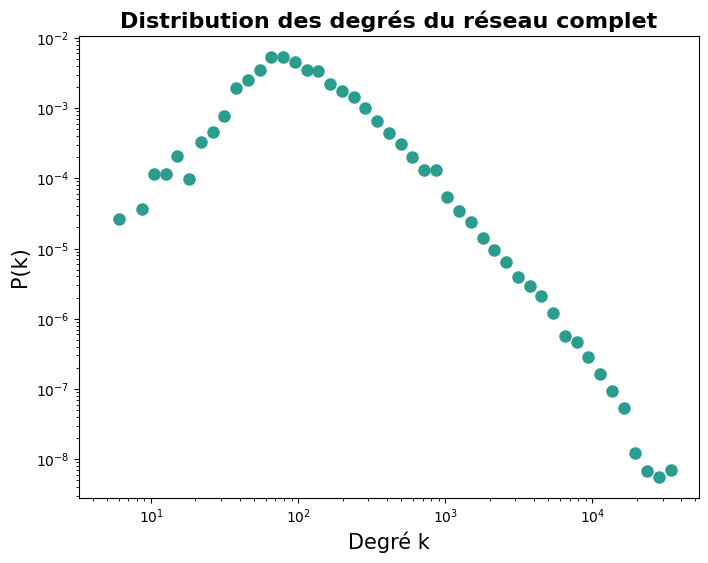

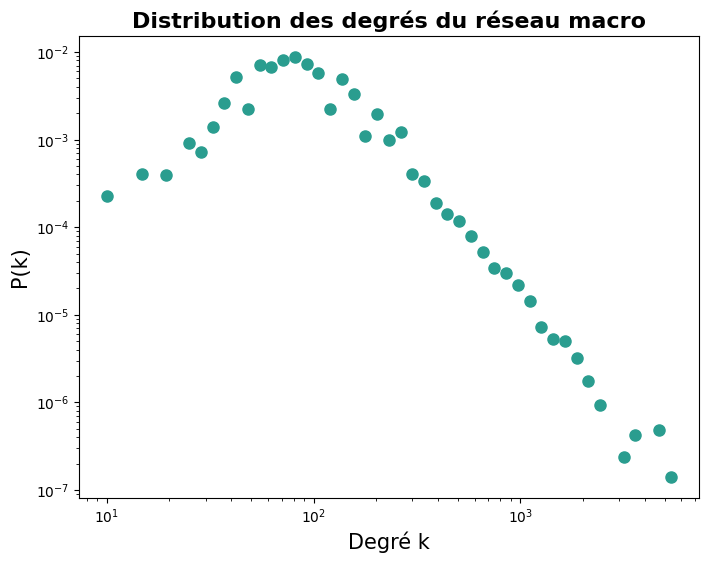

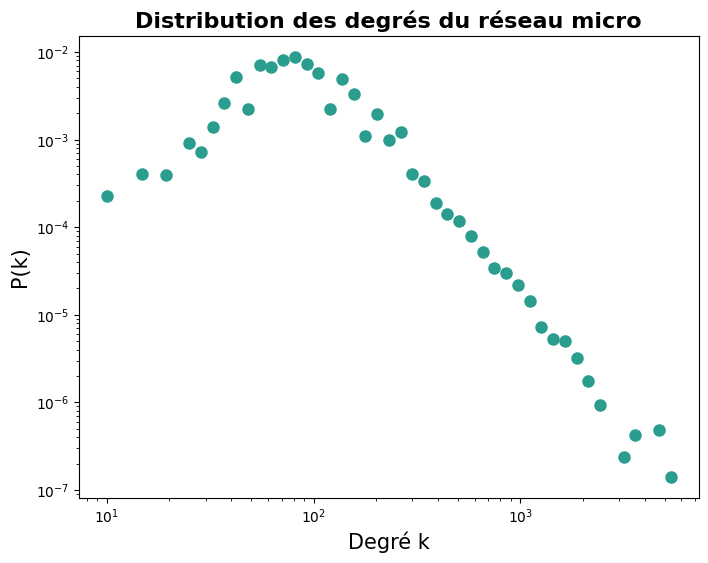

In [12]:
# Distributions des degrés
degree_distribution(G_complet, titre='Distribution des degrés du réseau complet')
degree_distribution(G_macro, titre='Distribution des degrés du réseau macro')
degree_distribution(G_macro, titre='Distribution des degrés du réseau micro')

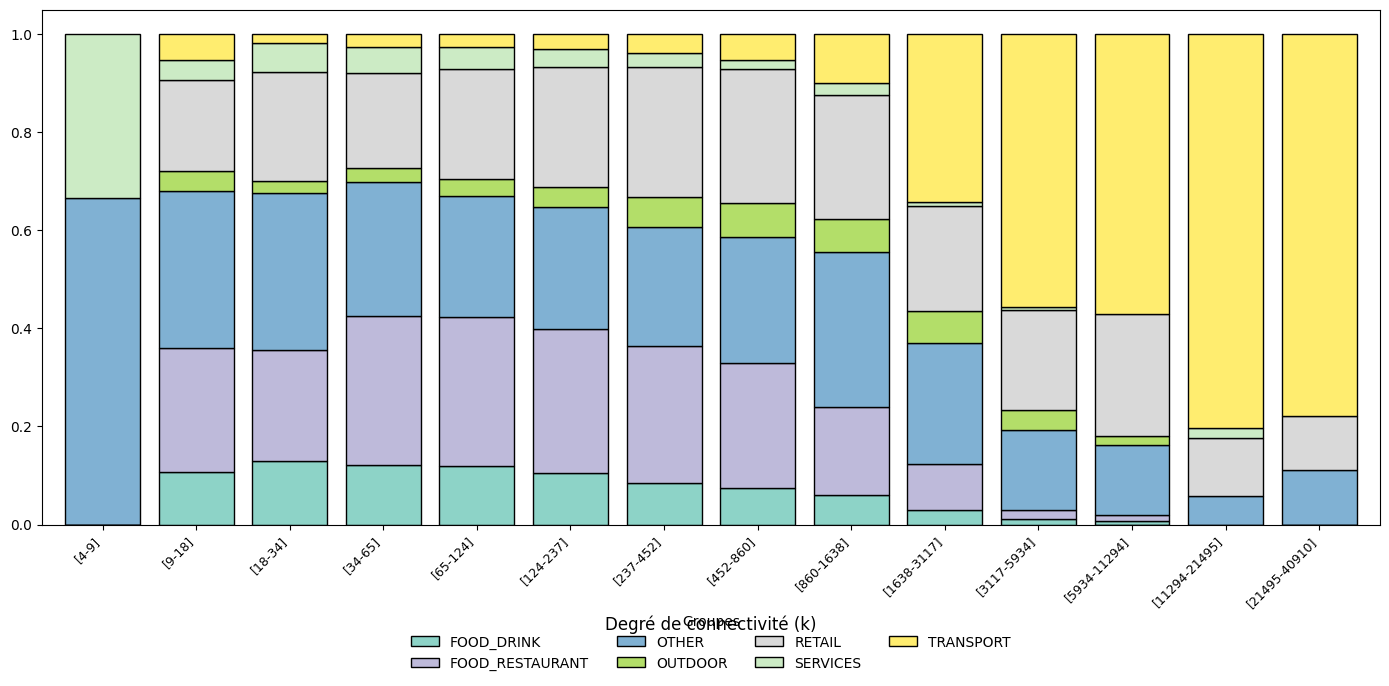

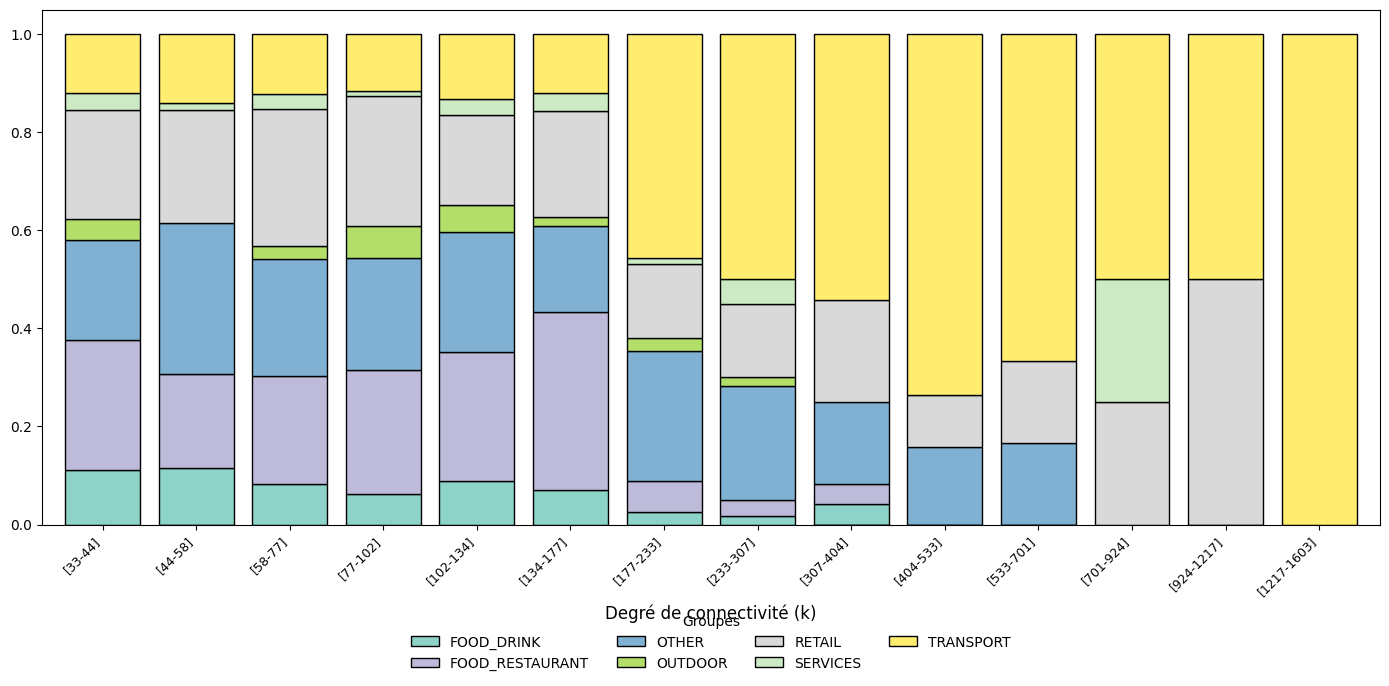

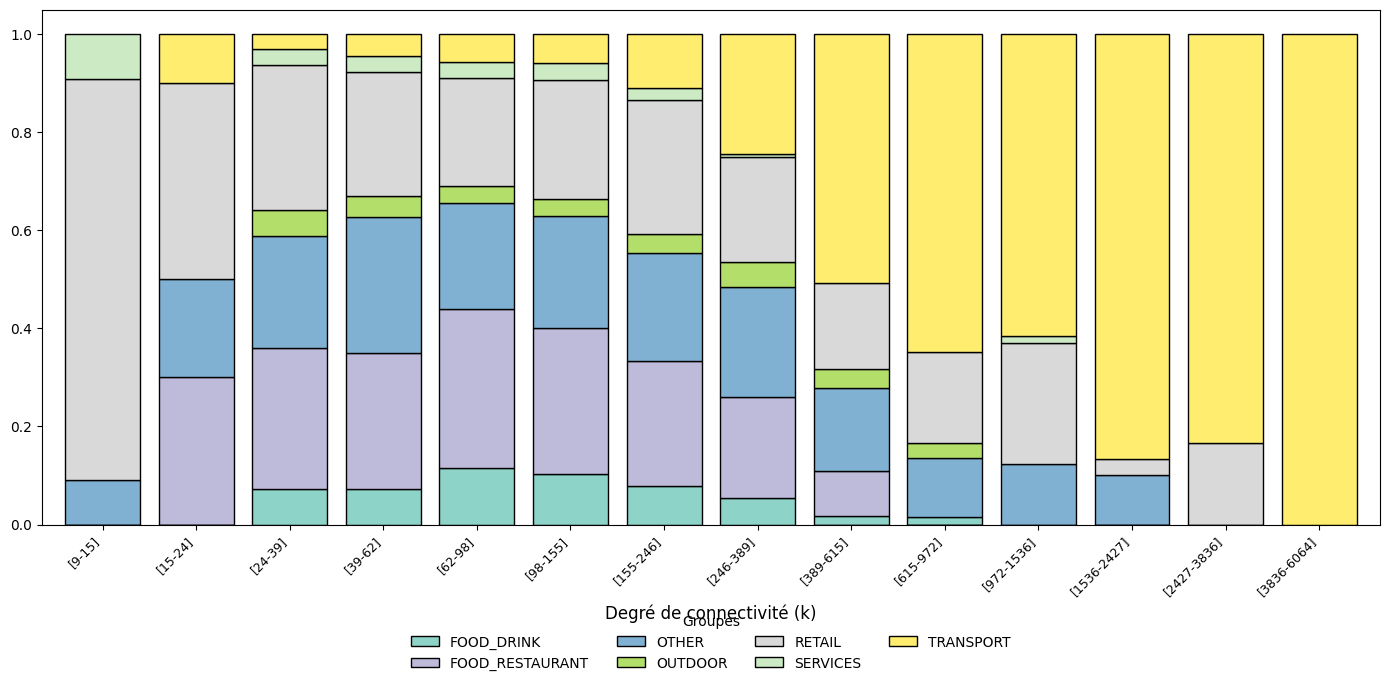

In [13]:
# Répartition des différentes catégories par intervalle de degrés
plot_stacked_degree_categories(G_complet)
plot_stacked_degree_categories(G_micro)
plot_stacked_degree_categories(G_macro)

## Degree mixing
Objectif: répondre à la question qui se connecte avec qui?

In [14]:
kDict = dict(G_complet.degree())

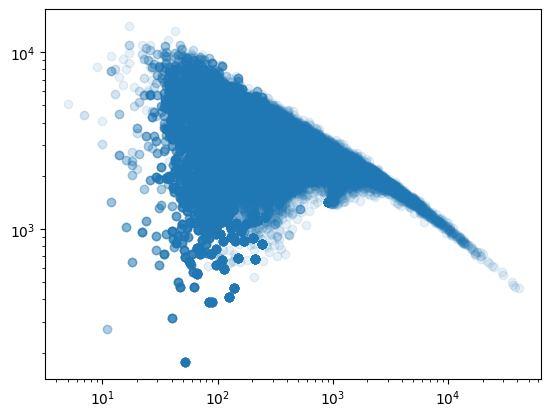

In [15]:
# Calcul du degré moyen de ses voisins pour chaque noeud
knn={}
for n in G_complet.nodes():
    neighbors_degrees=[kDict[v] for v in G_complet.neighbors(n)]
    knn[n]=np.mean(neighbors_degrees)


# Tracé de (k, neighbors_degrees_mean )
xx=[]
yy=[]
for n in knn.keys():
    xx.append(kDict[n])
    yy.append(knn[n])

plt.loglog(xx,yy,'o',alpha=0.1)

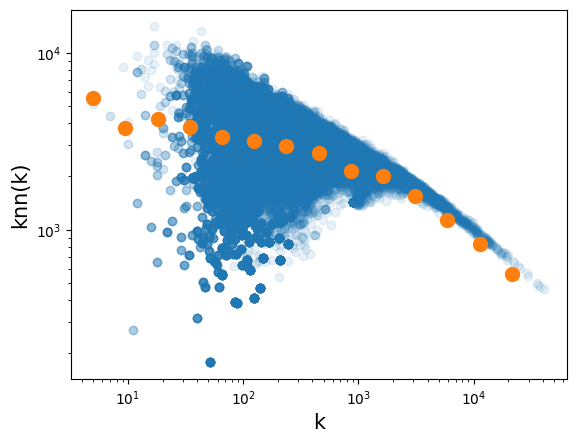

In [16]:
#  Nous regroupons les données dans des log-bins et nous traçons la moyenne de $knn$ pour chaque log-bin. 
xx=[]
yy=[]
for n in knn.keys():
    xx.append(kDict[n])
    yy.append(knn[n])

plt.loglog(xx,yy,'o',alpha=0.1)
logBins=np.logspace(np.log2(np.min(xx)),np.log2(np.max(xx)),base=2,num=15)
#if I use np.linspace I will have linear bins
ybin,xbin,binnumber=scipy.stats.binned_statistic(xx,yy,statistic='mean',bins=logBins)
plt.loglog(xbin[:-1],ybin,'o',markersize=10)

plt.xlabel('k',size=15)
plt.ylabel('knn(k)',size=15)
plt.show()

Il semblerait que tous les établissements soient connectés à des hubs.

## La propriété rich-club

La courbe est croissante sur la partie droite : plus un lieu est populaire, plus il a de chances d'être connecté à un autre lieu populaireLes lieux peu connectés semblent isolés, ce qui pourrait indiquer avec le graphique précédent qu'ils sont connectés à des hubs mais ne se connectent pas entre eux. A partir d'un certain seuil de popularité tous les lieux semblent connectés entre eux.

Pour s'assurer que l'hyperconnectivité des lieux les plus connectés n'est pas du à un simple effet mathématique, nous comparons cette courbe à un réseau aléatoire.



In [ ]:
dfjoint_complet.columns

Index(['user_id', 'checkins', 'n_checkins', 'gender', 'nb_twitter_friends',
       'nb_twitter_followers'],
      dtype='object')

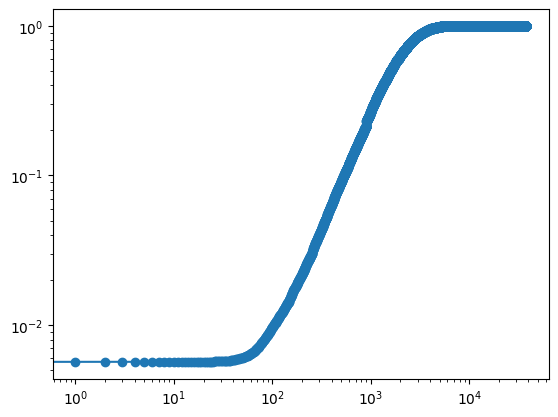

In [19]:
rc = nx.rich_club_coefficient(G_complet, normalized=False, seed=42)
plt.loglog(rc.keys(),rc.values(),'o-')

#### Comparaison avec un réseau aléatoire

Nous avons choisi comme réseau aléatoire un réseau BA comme vu en cours qui crée naturellement des hubs. Le choix est dicutable comme nous n'avons pas de loi puissance.
On observe une synergie entre les lieux qui ont entre 100 et 200 connections notamment : les utilisateurs ont tendance à naviguer entre ces lieux. La courbe redescend ensuite (et passe même en-dessous de la ligne représentant le modèle random(modèle BA dans ce cas)) : interprétation possible : les super_hubs sont connectés avec tout le monde.

<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_104431/1995856984.py:31: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\phi_{real} / \phi_{rand}$')


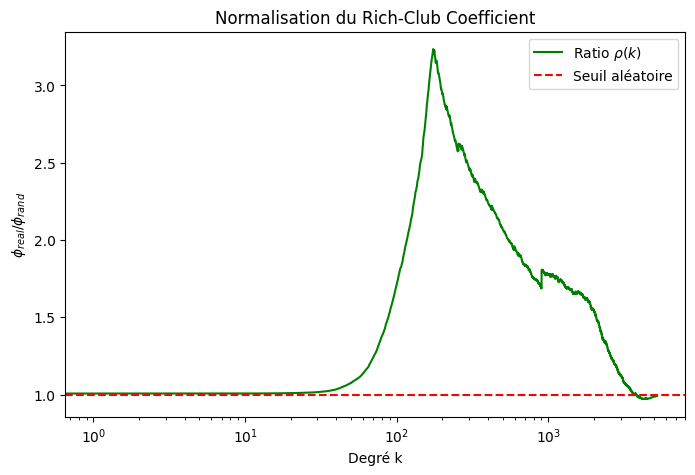

In [21]:


#  Création une version aléatoire de votre graphe G
# nswap définit le nombre de mélanges (plus il est haut, plus c'est aléatoire)
#G_random = nx.random_reference(G, nswap=G.number_of_edges() * 2, seed=42)

# Calculer le rich-club pour les deux
rc_real = nx.rich_club_coefficient(G_complet, normalized=False)
#rc_rand = nx.rich_club_coefficient(G_random, normalized=False)

# N : nombre de nœuds de votre graphe réel
# m : nombre d'arêtes à attacher pour chaque nouveau nœud
# (On estime m par : nombre_total_aretes / nombre_total_noeuds)
N = G_complet.number_of_nodes()
m = int(G_complet.number_of_edges() / N)

G_ba = nx.barabasi_albert_graph(N, m)

# Calcul du rich-club pour comparer
rc_ba = nx.rich_club_coefficient(G_ba, normalized=False)

# Calculer le ratio de normalisation (rho)
# On s'assure de ne comparer que les degrés présents dans les deux
common_k = sorted(set(rc_real.keys()) & set(rc_ba.keys()))
rho = [rc_real[k] / rc_ba[k] for k in common_k]

#  Tracer le résultat
plt.figure(figsize=(8, 5))
plt.plot(common_k, rho, 'g-', label="Ratio $\\rho(k)$")
plt.axhline(y=1, color='r', linestyle='--', label="Seuil aléatoire")
plt.xscale('log')
plt.xlabel('Degré k')
plt.ylabel('$\phi_{real} / \phi_{rand}$')
plt.title('Normalisation du Rich-Club Coefficient')
plt.legend()
plt.show()

## Rich-club followers

Construction d'un indice rich-club au regard du nombre de followers pour tenter de répondre à la question les lieux visités par les individus se connectent-ils davantage entre eux que ce que laisserait supposer le hasard (effet de réseau)?

In [6]:
loc_users = build_location_users(dfjoint_complet)
G = add_location_popularity(G_complet, dfjoint_complet, df_users)

✔ location_users construit
exemple: [('4b396b34f964a5204f5c25e3', ['1', '12', '14', '14', '14', '14', '14', '14', '14', '14', '14', '14', '14', '14', '14', '14', '14', '14', '22', '26', '26', '35', '45', '45', '50', '63', '103', '110', '113', '113', '124', '124', '135', '135', '136', '136', '168', '174', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '187', '194', '194', '194', '194', '196', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '211', '217', '217', '232', '232', '232', '233', '235', '235', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '236', '242', '242', '246', '251', '251', '251', '251', '251', '251', '251', '287', '

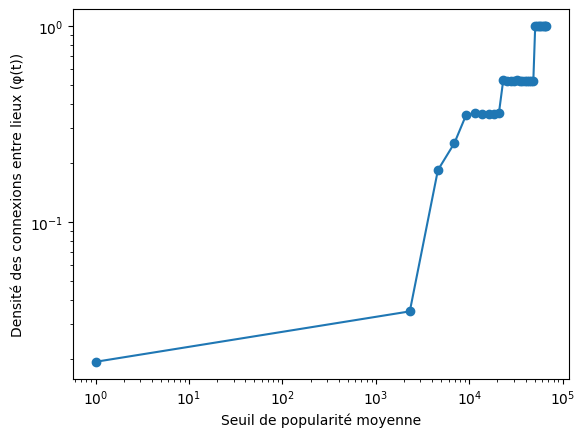

In [8]:
# Calcul d'un indice rich-club au regard du nombre moyen de followers des utilisateurs de chaque établissement
t, c = popularity_club_coefficient(G, n_bins=30)

plt.loglog(t, c, 'o-')
plt.xlabel("Seuil de popularité moyenne")
plt.ylabel("Densité des connexions entre lieux (φ(t))")
plt.show()